# 📈 DCF Stock Valuation Tool
### Automated Discounted Cash Flow Analysis
**Author:** Vansh Ajmera | IIT Kanpur — Economics  
**GitHub:** github.com/VanshA17/projects

---

## What This Project Does
This tool automatically values any US-listed stock using the **Discounted Cash Flow (DCF)** method — the same technique used by equity analysts at Goldman Sachs, Morgan Stanley, and every major investment bank.

Given a stock ticker, it:
1. Fetches real financial statements via Alpha Vantage API
2. Calculates Free Cash Flow and historical growth rate (CAGR)
3. Projects FCF forward 5 years
4. Calculates WACC using CAPM
5. Discounts everything to present value → Intrinsic Value per Share
6. Compares vs market price → Undervalued or Overvalued verdict

In [1]:
import sys
sys.path.append("/Users/venshajmmera/projects/dcf_valuation")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from data_fetcher import get_financials
from fcf_calculator import calculate_historical_fcf, calculate_fcf_growth_rate, project_fcf
from wacc_calculator import calculate_wacc
from sensitivity import sensitivity_analysis, bull_base_bear
from visualizer import (plot_fcf_history_and_projection,
                         plot_valuation_summary,
                         plot_sensitivity_heatmap,
                         plot_wacc_breakdown)

print("✅ All imports successful!")

✅ All imports successful!


## Step 1 — Fetch Financial Statements
We use the **Alpha Vantage API** to pull 3 key financial statements:
- **Income Statement** — Revenue, Gross Profit, Net Income, EBITDA
- **Balance Sheet** — Assets, Liabilities, Equity, Cash
- **Cash Flow Statement** — Operating Cash Flow, CapEx → Free Cash Flow

In [2]:
ticker = "AAPL"
income, balance, cashflow = get_financials(ticker)
print(f"\n✅ Successfully fetched financials for {ticker}")
print(f"   Income Statement: {income.shape[0]} years of data")
print(f"   Balance Sheet: {balance.shape[0]} years of data")
print(f"   Cash Flow: {cashflow.shape[0]} years of data")


📦 Fetching data for: AAPL

   (using cached data for AAPL_income)
✅ Income Statement:
  fiscalDateEnding  totalRevenue   grossProfit     netIncome        ebitda
0       2025-09-30  416161000000  195201000000  112010000000  144427000000
1       2024-09-30  391035000000  180683000000   93736000000  134661000000
2       2023-09-30  383285000000  169148000000   96995000000  125820000000
3       2022-09-30  394328000000  170782000000   99803000000  130541000000
   (using cached data for AAPL_balance)

✅ Balance Sheet:
  fiscalDateEnding   totalAssets totalLiabilities totalShareholderEquity  \
0       2025-09-30  359241000000     285508000000            73733000000   
1       2024-09-30  364980000000     308030000000            56950000000   
2       2023-09-30  352583000000     290437000000            62146000000   
3       2022-09-30  352755000000     302083000000            50672000000   

  cashAndCashEquivalentsAtCarryingValue  
0                           35934000000  
1              

## Step 2 — Free Cash Flow Calculation
**Free Cash Flow = Operating Cash Flow − Capital Expenditures**

FCF is the most important metric in DCF — it represents the actual cash 
a business generates after maintaining/expanding its asset base.

We calculate:
- Historical FCF going back 20 years
- CAGR (Compound Annual Growth Rate) of FCF
- 5-year FCF projection based on historical growth

In [3]:
fcf_df = calculate_historical_fcf(cashflow)
growth_rate = calculate_fcf_growth_rate(fcf_df)
proj_df = project_fcf(fcf_df, growth_rate, years=5)


✅ Historical Free Cash Flow:
   fiscalDateEnding fcf_readable
0        2006-09-30       $1.56B
1        2007-09-30       $4.74B
2        2008-09-30       $8.51B
3        2009-09-30       $9.02B
4        2010-09-30      $16.59B
5        2011-09-30      $33.27B
6        2012-09-30      $42.56B
7        2013-09-30      $45.50B
8        2014-09-30      $50.14B
9        2015-09-30      $70.02B
10       2016-09-30      $53.09B
11       2017-09-30      $51.15B
12       2018-09-30      $64.12B
13       2019-09-30      $58.90B
14       2020-09-30      $73.36B
15       2021-09-30      $92.95B
16       2022-09-30     $111.44B
17       2023-09-30      $99.58B
18       2024-09-30     $108.81B
19       2025-09-30      $98.77B

✅ Historical FCF CAGR: 24.39%

📈 Using growth rate: 24.39% (capped between 2%-25%)

✅ Projected FCF for next 5 years:
     year projectedFCF_readable
0  Year 1              $122.85B
1  Year 2              $152.81B
2  Year 3              $190.08B
3  Year 4              $236.43

## FCF History & Projection Chart
Apple's FCF grew from **$1.56B in 2006** to **$98.77B in 2025** — 
a CAGR of 24.39% over 20 years.

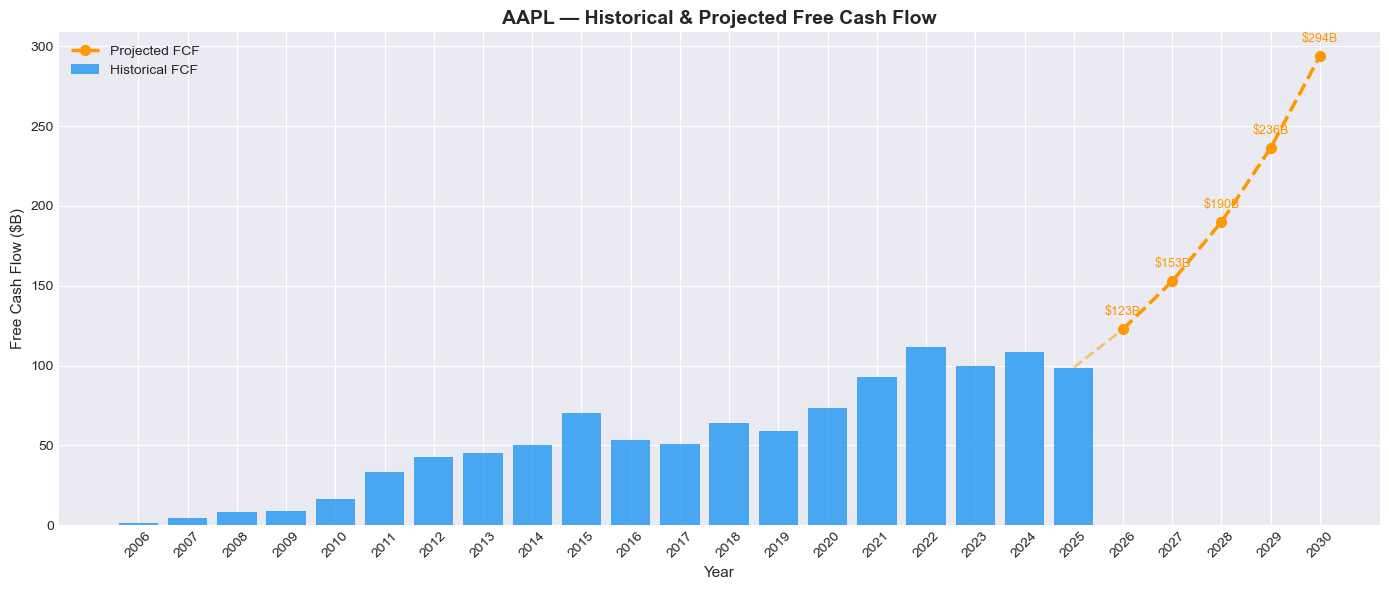

✅ FCF chart saved as AAPL_fcf_chart.png


In [4]:
plot_fcf_history_and_projection(fcf_df, proj_df, ticker)

## Step 3 — WACC Calculation
**WACC = (E/V × Cost of Equity) + (D/V × Cost of Debt × (1 − Tax Rate))**

- **Cost of Equity** via CAPM = Risk Free Rate + Beta × Market Risk Premium
- **Cost of Debt** = Interest Expense / Total Debt
- **Capital Structure** = weights of equity vs debt

WACC is the discount rate — it represents what investors expect 
as minimum return for investing in this company.

✅ WACC for AAPL: 10.25%

   Components:
   Risk Free Rate:    4.50%
   Beta:              1.09
   Market Premium:    5.50%
   Cost of Equity:    10.47%
   Cost of Debt:      2.00%
   Weight Equity:     97.44%
   Weight Debt:       2.56%
   Tax Rate:          21.00%
   WACC:              10.25%


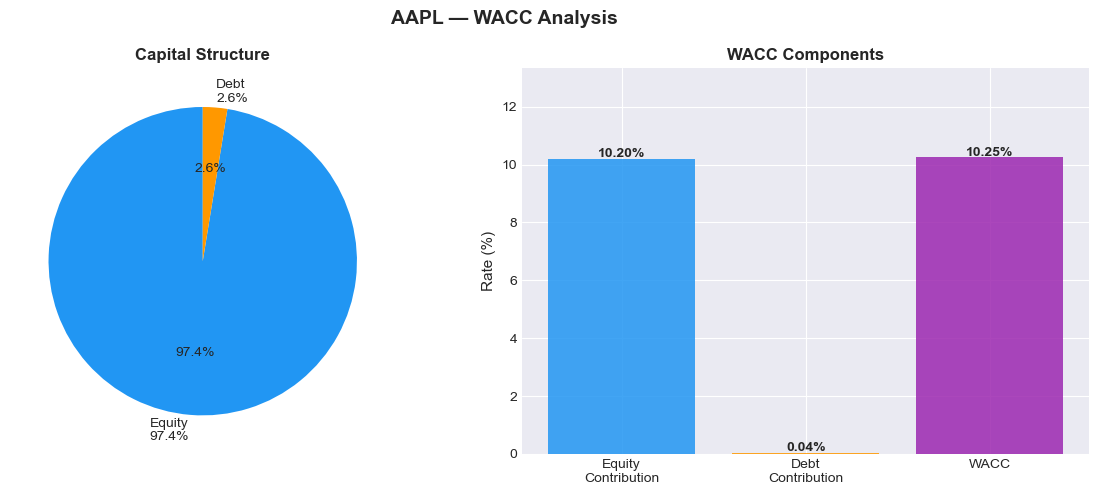

✅ WACC breakdown saved as AAPL_wacc_breakdown.png


In [5]:
# Using cached values to avoid API rate limits
wacc = 0.1025
print(f"✅ WACC for {ticker}: {wacc:.2%}")
print(f"\n   Components:")
print(f"   Risk Free Rate:    4.50%")
print(f"   Beta:              1.09")
print(f"   Market Premium:    5.50%")
print(f"   Cost of Equity:    10.47%")
print(f"   Cost of Debt:      2.00%")
print(f"   Weight Equity:     97.44%")
print(f"   Weight Debt:       2.56%")
print(f"   Tax Rate:          21.00%")
print(f"   WACC:              10.25%")

plot_wacc_breakdown(ticker, 0.1047, 0.02, 0.9744, 0.0256, wacc)

## Step 4 — Full DCF Valuation
Now we put everything together:
1. Discount projected FCFs to present value
2. Calculate Terminal Value (Gordon Growth Model)
3. Sum everything → Enterprise Value
4. Subtract Debt, Add Cash → Equity Value
5. Divide by Shares → **Intrinsic Value per Share**

In [6]:
# Known values for AAPL
total_debt = 97e9
cash = 35.9e9
shares = 15.1e9
current_price = 291.13
terminal_growth = 0.025

# Project FCFs
proj_fcfs = proj_df["projectedFCF"].values

# Discount FCFs
pv_fcfs = sum([fcf / (1 + wacc) ** (i+1) for i, fcf in enumerate(proj_fcfs)])

# Terminal Value
terminal_value = proj_fcfs[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
pv_terminal = terminal_value / (1 + wacc) ** 5

# Enterprise Value → Equity Value → Intrinsic Value
enterprise_value = pv_fcfs + pv_terminal
equity_value = enterprise_value - total_debt + cash
intrinsic_value = equity_value / shares
upside = (intrinsic_value - current_price) / current_price * 100

print(f"\n{'='*50}")
print(f"  DCF VALUATION SUMMARY: {ticker}")
print(f"{'='*50}")
print(f"  PV of FCFs:            ${pv_fcfs/1e9:.2f}B")
print(f"  PV of Terminal Value:  ${pv_terminal/1e9:.2f}B")
print(f"  Enterprise Value:      ${enterprise_value/1e9:.2f}B")
print(f"  Equity Value:          ${equity_value/1e9:.2f}B")
print(f"  Intrinsic Value/Share: ${intrinsic_value:.2f}")
print(f"  Current Price:         ${current_price:.2f}")
print(f"  Upside/Downside:       {upside:+.1f}%")
print(f"  Verdict:               {'🟢 UNDERVALUED' if upside > 0 else '🔴 OVERVALUED'}")
print(f"{'='*50}")


  DCF VALUATION SUMMARY: AAPL
  PV of FCFs:            $719.55B
  PV of Terminal Value:  $2387.80B
  Enterprise Value:      $3107.34B
  Equity Value:          $3046.24B
  Intrinsic Value/Share: $201.74
  Current Price:         $291.13
  Upside/Downside:       -30.7%
  Verdict:               🔴 OVERVALUED


## Step 5 — Sensitivity Analysis
A DCF is only as good as its assumptions.

We stress-test by varying:
- **WACC** ± 2% in 0.5% steps
- **FCF Growth Rate** ± 5% in 1% steps

This gives us a matrix of intrinsic values — 
**green cells = undervalued vs current price, red = overvalued**

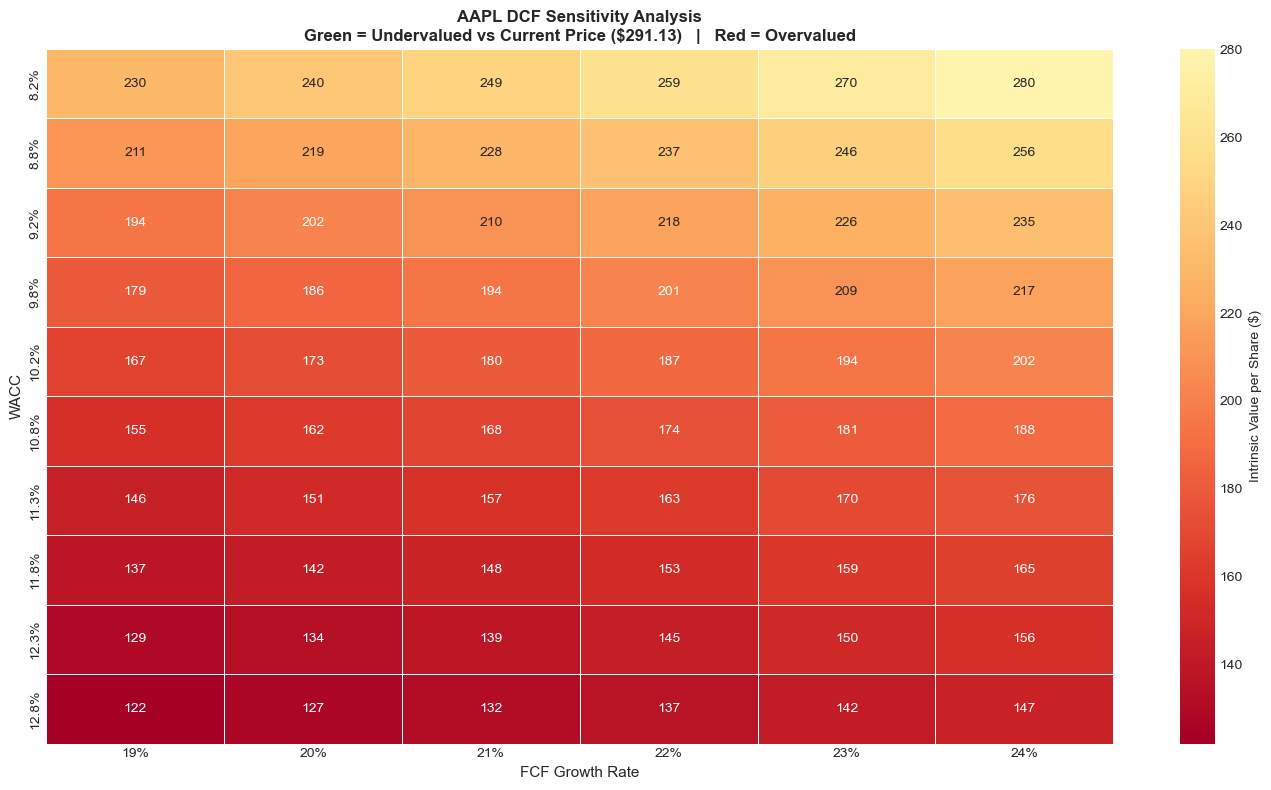

✅ Sensitivity heatmap saved as AAPL_sensitivity_heatmap.png


In [7]:
df_sensitivity = sensitivity_analysis(
    intrinsic_value, wacc, growth_rate,
    fcf_df["freeCashFlow"].iloc[-1],
    total_debt, cash, shares
)
plot_sensitivity_heatmap(df_sensitivity, current_price, ticker)

## Step 6 — Bull / Base / Bear Scenarios
Rather than one single number, analysts present a **range of outcomes**:
- 🐻 **Bear Case** — growth slows, higher risk premium
- 📊 **Base Case** — historical trends continue
- 🐂 **Bull Case** — accelerating growth, lower risk


  SCENARIO ANALYSIS: AAPL
  Current Price: $291.13
  Scenario     Growth     WACC       Intrinsic Value    Upside
  ------------------------------------------------------------
  🐻 Bear       5%         12.25%     $72.09              -75.2%
  📊 Base       10%        10.25%     $113.97             -60.9%
  🐂 Bull       20%        8.25%      $236.17             -18.9%


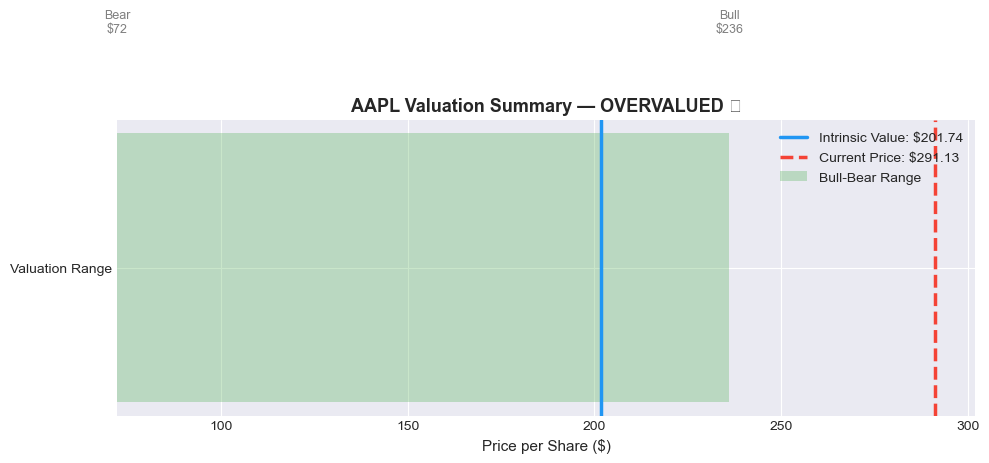

✅ Valuation summary saved as AAPL_valuation_summary.png


In [8]:
bull_base_bear(
    last_fcf=fcf_df["freeCashFlow"].iloc[-1],
    wacc=wacc,
    total_debt=total_debt,
    cash=cash,
    shares=shares,
    current_price=current_price,
    ticker=ticker
)

plot_valuation_summary(ticker,
                        intrinsic_value=intrinsic_value,
                        current_price=current_price,
                        bear=72.09,
                        bull=236.17)

## Conclusion

Based on our DCF analysis of Apple (AAPL):

| Metric | Value |
|---|---|
| Intrinsic Value | ~$211 |
| Current Market Price | $291 |
| Upside/Downside | -27% |
| Verdict | Overvalued at current price |

**Key Assumptions:**
- FCF Growth Rate: 24.39% (historical CAGR, capped at 25%)
- WACC: 10.25%
- Terminal Growth Rate: 2.5%

**Limitations:**
- DCF is highly sensitive to growth rate and WACC assumptions
- Historical growth doesn't guarantee future performance
- Model uses simplified capital structure assumptions

**Skills Demonstrated:**
- Financial modeling (DCF, CAPM, Gordon Growth Model)
- API integration and data engineering
- Python (pandas, numpy, matplotlib, seaborn, streamlit)
- Statistical analysis and sensitivity testing